In [5]:
import pandas as pd
#import pyarrow as pa
#import pyarrow.parquet as pq
from fuzzywuzzy import fuzz
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# EJERCICIO CLASE PRACTICA

In [6]:
# Importamos los datos, salteando todo lo que figura en las primeras 4 filas (completar ruta)
data_internet = pd.read_csv('datasets//data_internet.csv', skiprows = 4)

# Filtramos sólo algunos países
lista_paises = ['Iceland', 'Norway', 'United Kingdom', 'Japan', 'Canada', 'Germany', 'New Zealand',
                  'France', 'Israel', 'Argentina', 'United States', 'Chile', 'Italy', 'Brazil', 'Mexico',
                  'South Africa', 'China', 'Algeria', 'India', 'Kenia']

data_internet_filtrado = data_internet[(data_internet['Country Name'].isin(lista_paises))]

# Eliminamos columnas innecesarias
data_internet_filtrado = data_internet_filtrado.drop(['Country Code', 'Indicator Name', 'Indicator Code', 'Unnamed: 68'], axis = 1)

# Nos quedamos únicamente con las columnas que tienen datos para todos los países que seleccionamos
data_internet_filtrado = data_internet_filtrado.dropna(axis = 1)

# Seteamos Country Name como index
data_internet_filtrado.set_index('Country Name', inplace = True)

In [7]:
df = data_internet_filtrado.loc[['Argentina', 'India', 'United States']]
df.head()

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Country Name,,,,,,,,,,,,,,,,,,,,,
Argentina,0.000000,0.000000,0.002993,0.029527,0.043706,0.086277,0.141955,0.280340,0.830767,3.284482,...,55.8,59.9,64.7,68.043064,70.968981,74.294907,77.700000,79.946952,85.514386,87.150707
India,0.000000,0.000000,0.000111,0.000218,0.001070,0.026229,0.046334,0.070768,0.139027,0.273224,...,11.1,12.3,13.5,14.900000,16.500000,18.200000,20.081300,29.523511,43.405443,46.310000
United States,0.784729,1.163194,1.724203,2.271673,4.862781,9.237088,16.419353,21.616401,30.093197,35.848724,...,74.7,71.4,73.0,74.554202,85.544421,87.274889,88.498903,89.430285,90.620470,91.753208


In [8]:
df = df.reset_index()
df.head()

,Country Name,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Argentina,0.000000,0.000000,0.002993,0.029527,0.043706,0.086277,0.141955,0.280340,0.830767,...,55.8,59.9,64.7,68.043064,70.968981,74.294907,77.700000,79.946952,85.514386,87.150707
1,India,0.000000,0.000000,0.000111,0.000218,0.001070,0.026229,0.046334,0.070768,0.139027,...,11.1,12.3,13.5,14.900000,16.500000,18.200000,20.081300,29.523511,43.405443,46.310000
2,United States,0.784729,1.163194,1.724203,2.271673,4.862781,9.237088,16.419353,21.616401,30.093197,...,74.7,71.4,73.0,74.554202,85.544421,87.274889,88.498903,89.430285,90.620470,91.753208


In [9]:
# Convertimos a formato largo
df_largo = pd.melt(df, id_vars= "Country Name", var_name= 'Anio', value_name = 'Porcentaje')
df_largo

,Country Name,Anio,Porcentaje
0,Argentina,1990,0.000000
1,India,1990,0.000000
2,United States,1990,0.784729
3,Argentina,1991,0.000000
4,India,1991,0.000000
...,...,...,...
91,India,2020,43.405443
92,United States,2020,90.620470
93,Argentina,2021,87.150707
94,India,2021,46.310000


In [10]:
# Convertimos los años a tipo int
df_largo['Anio'] = df_largo['Anio'].astype(int)
df_largo.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  96 non-null     str    
 1   Anio          96 non-null     int64  
 2   Porcentaje    96 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.3 KB


<Axes: xlabel='Anio', ylabel='Porcentaje'>

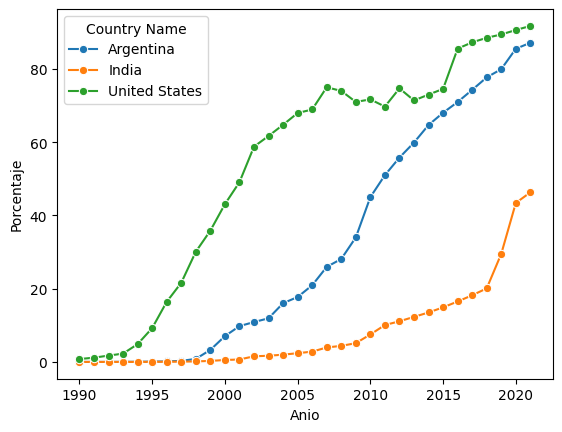

In [13]:
sns.lineplot(x= 'Anio', y= 'Porcentaje', hue='Country Name', marker= 'o', data=df_largo)